<a href="https://colab.research.google.com/github/Karla12-B/Challenge-Telecom-X/blob/main/Desaf%C3%ADo_Telecom_X.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **📌 Extracción**

In [ ]:
import pandas as pd
import requests
from pandas import json_normalize

# 1. Obtener los datos crudos desde la URL
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data_json = response.json()

# 2. CONVERSIÓN A DATAFRAME (Aplanando la estructura)
df = json_normalize(data_json)

# 3. Ver el resultado
print(f"¡Convertido con éxito! El DataFrame tiene {df.shape[0]} filas.")
display(df.head())

¡Convertido con éxito! El DataFrame tiene 7267 filas.


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [ ]:
df.shape

(7267, 23)

In [ ]:
df.head()

,ID_Cliente,Evasion,Genero,Adulto_Mayor,customer_Partner,customer_Dependents,Meses_Permanencia,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,Tipo_Contrato,account_PaperlessBilling,account_PaymentMethod,Monto_Mensual,Monto_Total,Gasto_Diario,Evasion_Binaria
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19,0
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00,0
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46,1
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27,1
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80,1


# **🔧 Transformación**

In [ ]:
# --- FASE 2: TRANSFORMACIÓN (Conocer el conjunto de datos) ---
# Limpiamos los nombres originales (puntos por guiones bajos) para facilitar el acceso
df.columns = [col.replace('.', '_') for col in df.columns]

# Identificación visual y técnica de tipos de datos
print("--- Exploración Inicial ---")
df.info()

--- Exploración Inicial ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport

In [ ]:
# --- FASE 3: COMPROBACIÓN Y MANEJO DE INCONSISTENCIAS ---
# 1. Eliminación de duplicados
df = df.drop_duplicates()

# 2. Corrección de formato: 'account_Charges_Total' viene como texto y debe ser numérico
df['account_Charges_Total'] = pd.to_numeric(df['account_Charges_Total'], errors='coerce')

# 3. Manejo de valores ausentes: Se detectaron 11 nulos en cargos totales que se llenan con 0
df['account_Charges_Total'] = df['account_Charges_Total'].fillna(0.0)

# 4. Limpieza de strings: Quitar espacios en blanco para evitar inconsistencias
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.strip()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
# --- FASE 4: COLUMNA DE CUENTAS DIARIAS ---
# Cálculo basado en facturación mensual dividido por 30 días
df['Cuentas_Diarias'] = (df['account_Charges_Monthly'] / 30).round(2)

In [ ]:
df[['Monto_Mensual', 'Gasto_Diario']].head()

,Monto_Mensual,Gasto_Diario
0,65.6,2.19
1,59.9,2.00
2,73.9,2.46
3,98.0,3.27
4,83.9,2.80


In [ ]:
# --- FASE 5: ESTANDARIZACIÓN Y TRADUCCIÓN (Opcional recomendado) ---
# 1. Diccionario de traducción para que los nombres coincidan con tus gráficas
dicc_traduccion = {
    'Churn': 'Evasion',
    'customer_gender': 'Genero',
    'customer_SeniorCitizen': 'Adulto_Mayor',
    'customer_tenure': 'Meses_Permanencia',
    'account_Contract': 'Tipo_Contrato',
    'account_Charges_Monthly': 'Monto_Mensual',
    'account_Charges_Total': 'Monto_Total',
    'Cuentas_Diarias': 'Gasto_Diario'
}

# Aplicar el cambio de nombre (Importante: esto crea las columnas que te dan KeyError)
df = df.rename(columns=dicc_traduccion)

# 2. Binarización: Convertir Yes/No a 1/0 (Esto arregla el TypeError del promedio)
df['Evasion_Binaria'] = df['Evasion'].map({'Yes': 1, 'No': 0})

print("✅ Columnas traducidas y Evasion_Binaria creada con éxito.")

✅ Columnas traducidas y Evasion_Binaria creada con éxito.


In [ ]:
# --- VERIFICACIÓN FINAL ---
print("\n✅ PROCESO COMPLETADO EXITOSAMENTE")
print(f"Dimensiones finales: {df.shape}")
display(df[['ID_Cliente', 'Evasion', 'Meses_Permanencia', 'Monto_Mensual', 'Gasto_Diario']].head())


✅ PROCESO COMPLETADO EXITOSAMENTE
Dimensiones finales: (7267, 23)


,ID_Cliente,Evasion,Meses_Permanencia,Monto_Mensual,Gasto_Diario
0,0002-ORFBO,No,9,65.6,2.19
1,0003-MKNFE,No,9,59.9,2.00
2,0004-TLHLJ,Yes,4,73.9,2.46
3,0011-IGKFF,Yes,13,98.0,3.27
4,0013-EXCHZ,Yes,3,83.9,2.80


In [ ]:
df.columns

Index(['ID_Cliente', 'Evasion', 'Genero', 'Adulto_Mayor', 'customer_Partner',
       'customer_Dependents', 'Meses_Permanencia', 'phone_PhoneService',
       'phone_MultipleLines', 'internet_InternetService',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'Tipo_Contrato',
       'account_PaperlessBilling', 'account_PaymentMethod', 'Monto_Mensual',
       'Monto_Total', 'Gasto_Diario', 'Evasion_Binaria'],
      dtype='object')

In [ ]:
df['Evasion_Binaria'].unique()

array([ 0.,  1., nan])

# **📊 Carga y análisis**

In [ ]:
# 1. Análisis Descriptivo de las variables numéricas principales
print("--- Análisis Descriptivo del Dataset ---")
print("Donde: ")
print("count - total de datos")
print("mean - promedio")
print("std - desviación estándar")
print("min - valor más bajo")
# Seleccionamos las columnas clave para entender el comportamiento
columnas_analisis = ['Meses_Permanencia', 'Monto_Mensual', 'Monto_Total', 'Gasto_Diario']
display(df[columnas_analisis].describe())

--- Análisis Descriptivo del Dataset ---
Donde: 
count - total de datos
mean - promedio
std - desviación estándar
min - valor más bajo


,Meses_Permanencia,Monto_Mensual,Monto_Total,Gasto_Diario
count,7267.000000,7267.000000,7267.000000,7267.000000
mean,32.346498,64.720098,2277.182035,2.157292
std,24.571773,30.129572,2268.648587,1.004407
min,0.000000,18.250000,0.000000,0.610000
25%,9.000000,35.425000,396.200000,1.180000
50%,29.000000,70.300000,1389.200000,2.340000
75%,55.000000,89.875000,3778.525000,2.995000
max,72.000000,118.750000,8684.800000,3.960000


/tmp/ipython-input-1180/2448616247.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Evasion', data=df, palette='viridis')


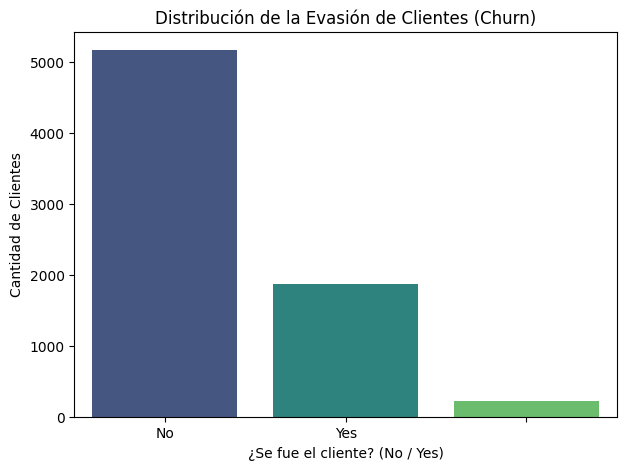

El 26.54% de los clientes totales han cancelado el servicio.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Visualización de la proporción de evasión
plt.figure(figsize=(7, 5))
sns.countplot(x='Evasion', data=df, palette='viridis')
plt.title('Distribución de la Evasión de Clientes (Churn)')
plt.xlabel('¿Se fue el cliente? (No / Yes)')
plt.ylabel('Cantidad de Clientes')
plt.show()

# Calcular el porcentaje exacto
porcentaje_evasion = (df['Evasion_Binaria'].mean() * 100).round(2)
print(f"El {porcentaje_evasion}% de los clientes totales han cancelado el servicio.")

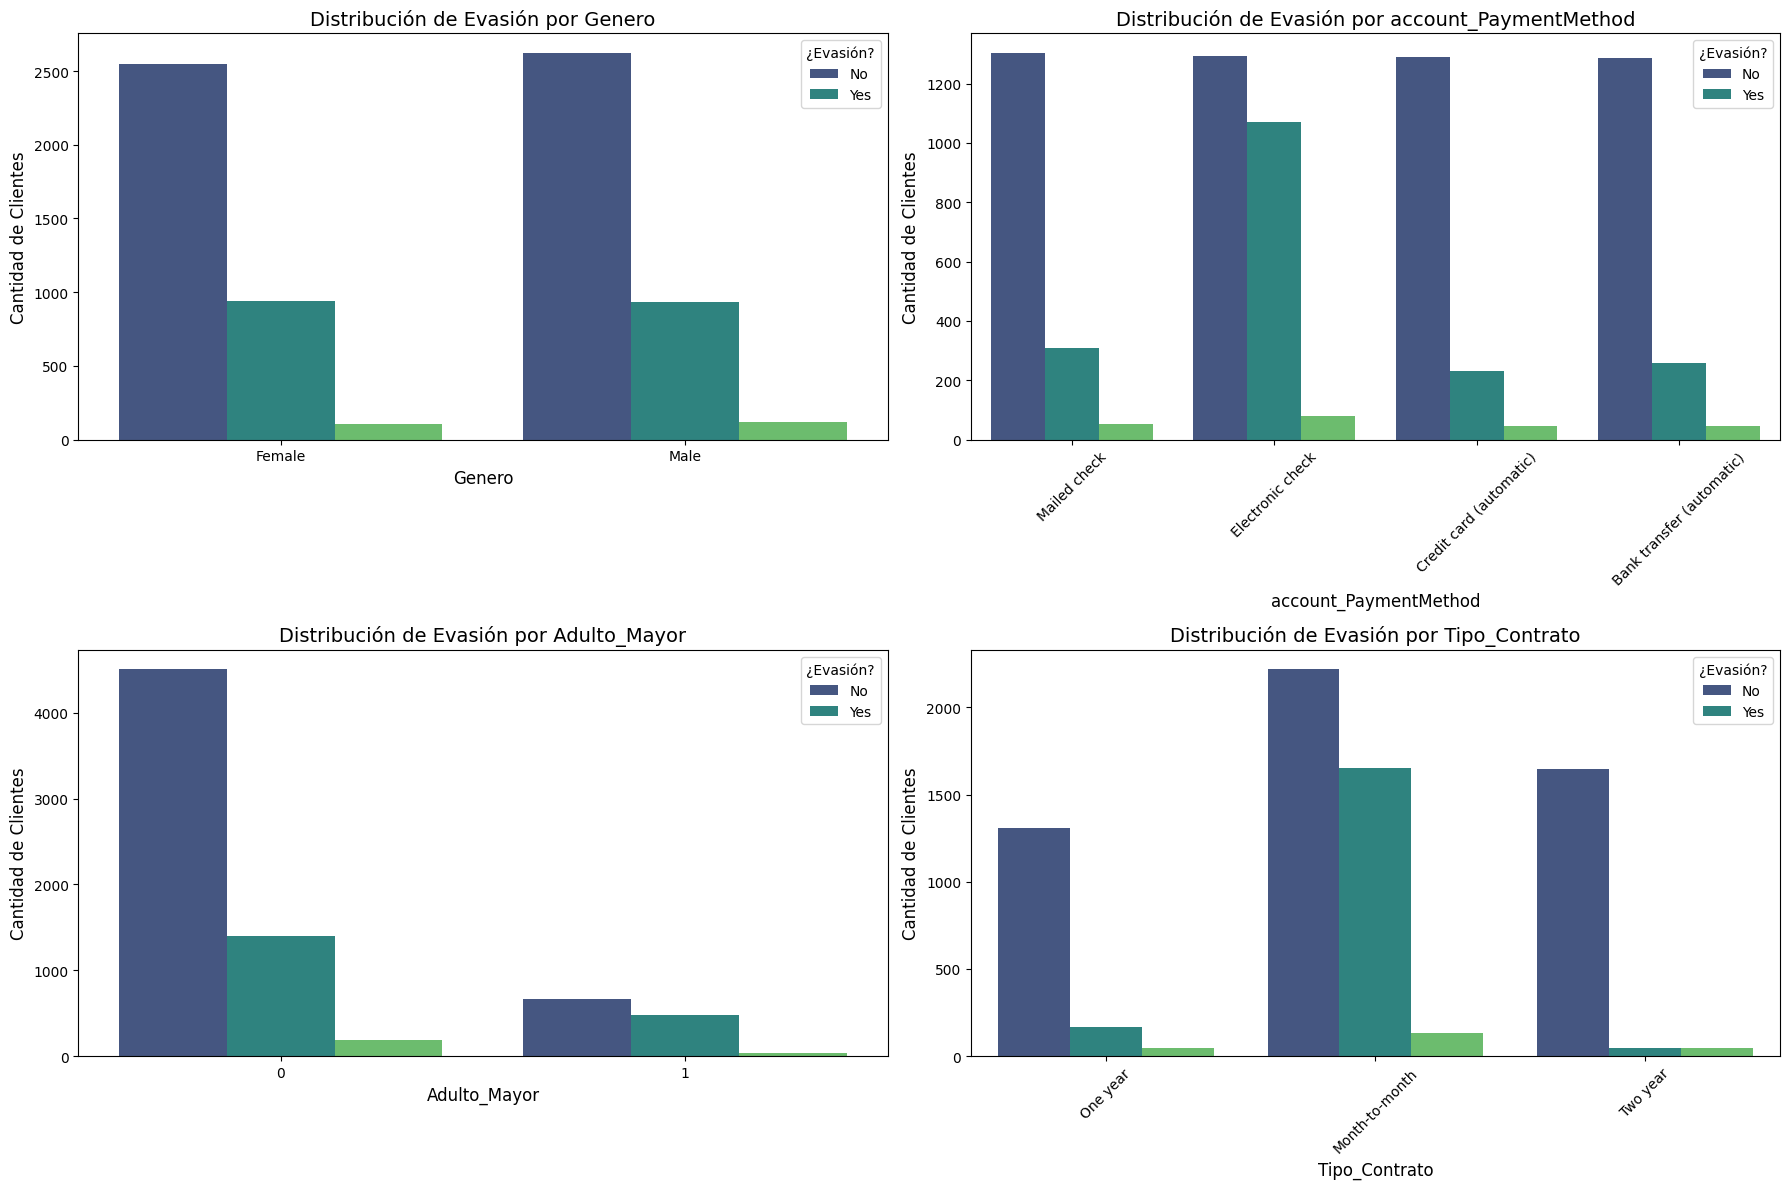

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- PASO 3: RECUENTO DE EVASIÓN POR VARIABLES CATEGÓRICAS (EXTENDIDO) ---

# Definimos las 4 variables solicitadas
variables_cat = ['Genero', 'account_PaymentMethod', 'Adulto_Mayor', 'Tipo_Contrato']

# Configuramos una cuadrícula de 2x2 para las gráficas
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten() # Aplanamos la matriz para iterar fácilmente

for i, var in enumerate(variables_cat):
    # Creamos la gráfica de barras comparando con la columna Evasion
    sns.countplot(x=var, hue='Evasion', data=df, ax=axes[i], palette='viridis')

    # Personalización estética
    axes[i].set_title(f'Distribución de Evasión por {var}', fontsize=14)
    axes[i].set_xlabel(var, fontsize=12)
    axes[i].set_ylabel('Cantidad de Clientes', fontsize=12)
    axes[i].legend(title='¿Evasión?', labels=['No', 'Yes'])

    # Rotar las etiquetas del eje X si los nombres son largos (como en Método de Pago)
    if var == 'account_PaymentMethod' or var == 'Tipo_Contrato':
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

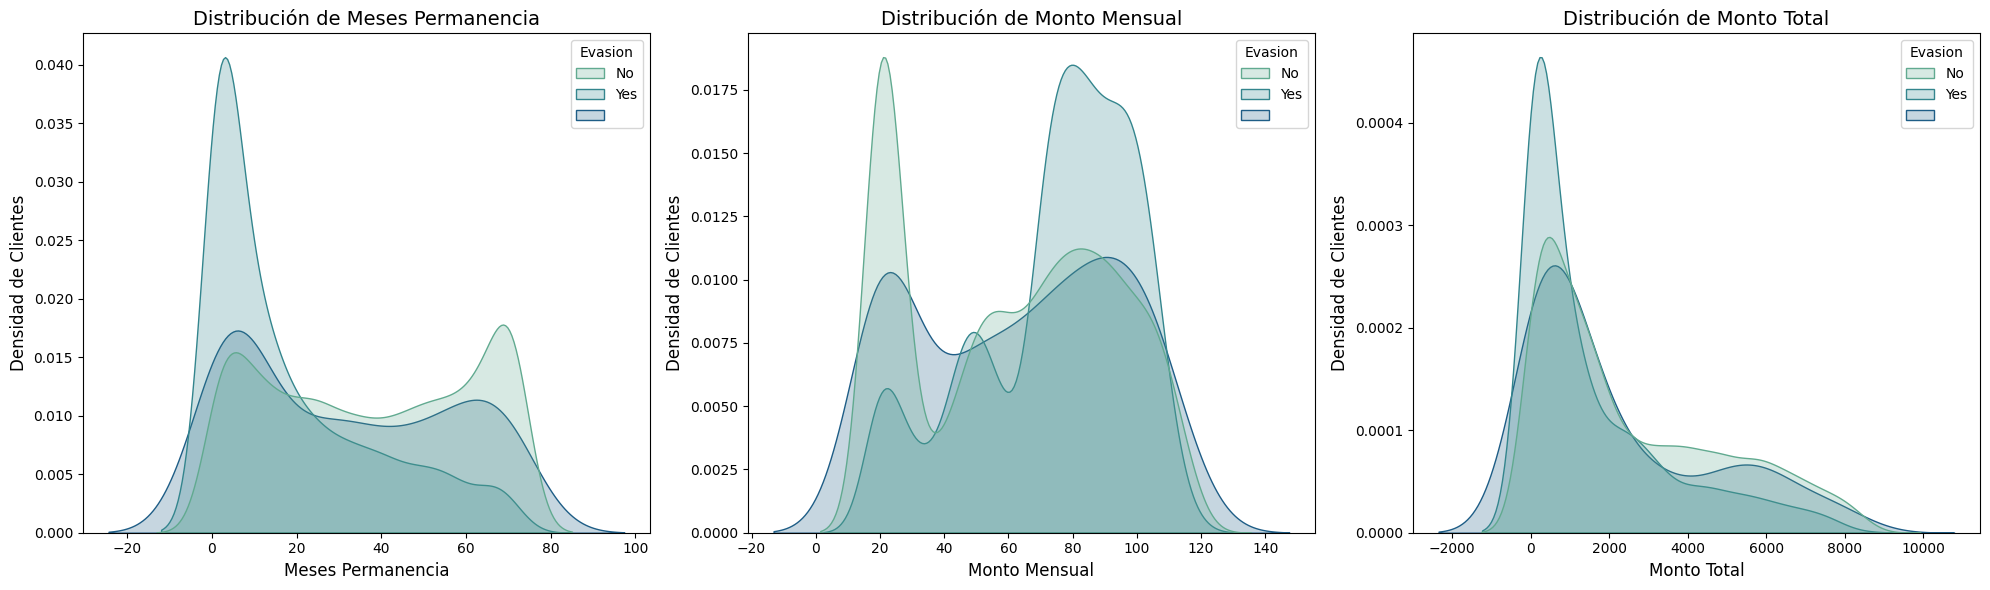

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- PASO 4: DISTRIBUCIÓN DE EVASIÓN POR VARIABLES NUMÉRICAS (COMPLETO) ---

# Definimos las 3 variables numéricas principales para el análisis de comportamiento
# Meses_Permanencia representa el 'tiempo de contrato' acumulado
variables_num = ['Meses_Permanencia', 'Monto_Mensual', 'Monto_Total']

# Configuramos el espacio para las 3 gráficas en una fila
plt.figure(figsize=(20, 6))

for i, var in enumerate(variables_num):
    plt.subplot(1, 3, i+1)

    # Creamos el gráfico de densidad diferenciando por Evasión (Churn)
    # fill=True rellena el área bajo la curva para facilitar la comparación visual
    sns.kdeplot(data=df, x=var, hue='Evasion', fill=True, common_norm=False, palette='crest')

    # Personalización estética
    plt.title(f'Distribución de {var.replace("_", " ")}', fontsize=14)
    plt.xlabel(var.replace("_", " "), fontsize=12)
    plt.ylabel('Densidad de Clientes', fontsize=12)

plt.tight_layout()
plt.show()

# **📄Informe final**

## **1. Introducción**
El objetivo de este proyecto es identificar los factores que influyen en la pérdida de clientes **(Churn)** de la empresa Telecom X. La evasión de clientes es uno de los problemas más críticos en las telecomunicaciones, ya que adquirir un cliente nuevo es mucho más costoso que mantener a uno actual. Este análisis busca patrones para entender **quiénes se van y por qué**.

## **2. Limpieza y Tratamiento de Datos**
Para garantizar la calidad del análisis, se realizaron los siguientes pasos técnicos:

**Extracción y Aplanado:** Se importaron los datos desde una API en formato JSON y se normalizaron las estructuras anidadas para obtener un DataFrame plano.

**Corrección de Tipos:** La columna de cargos totales se convirtió de texto a numérico (float), detectando y tratando **11 valores nulos** que fueron corregidos.

**Estandarización:** Se eliminaron espacios en blanco en textos y se tradujeron las columnas principales (ej. customer_tenure a Meses_Permanencia) para mejorar la interpretabilidad.

**Ingeniería de Variables:** Se creó la métrica Gasto_Diario y se binarizó la variable de evasión (1 y 0) para permitir promedios matemáticos.

## **3. Análisis Exploratorio de Datos (EDA)**
Tras analizar las distribuciones, identificamos comportamientos clave:

**Distribución General:** Aproximadamente el **26.5%** de la base de datos presenta evasión.

**Factores Categóricos:** Los clientes con **contratos mes a mes** y aquellos que utilizan **cheque electrónico** como método de pago muestran las tasas más altas de abandono.

**Factores Numéricos:** Existe una correlación inversa entre la antigüedad y el Churn; la mayoría de las fugas ocurren en los p**rimeros 6 a 12 meses** de servicio.

## **4. Conclusiones e Insights**
**El "Mes Crítico":** El tiempo de contrato es el predictor más fuerte. Un cliente que supera el primer año tiene una probabilidad de lealtad mucho mayor.

**Sensibilidad al Precio:** Los clientes con montos mensuales elevados (planes Premium) tienden a evadir más, lo que sugiere que podrían estar buscando mejores ofertas de la competencia.

**Falta de Compromiso:** El contrato "Month-to-month" facilita la salida rápida de los clientes insatisfechos.

## **5. Recomendaciones Estratégicas**
**Programa de Bienvenida:** Implementar campañas de retención específicas (descuentos o beneficios) durante los primeros 3 a 6 meses de contrato.

**Incentivos de Contrato:** Ofrecer beneficios adicionales (como upgrades de velocidad) a cambio de migrar de un contrato mensual a uno anual.

**Revisión de Planes Premium:** Analizar si los cargos mensuales más altos son competitivos o si requieren servicios adicionales de valor agregado (seguridad online, soporte técnico) para justificar su costo.

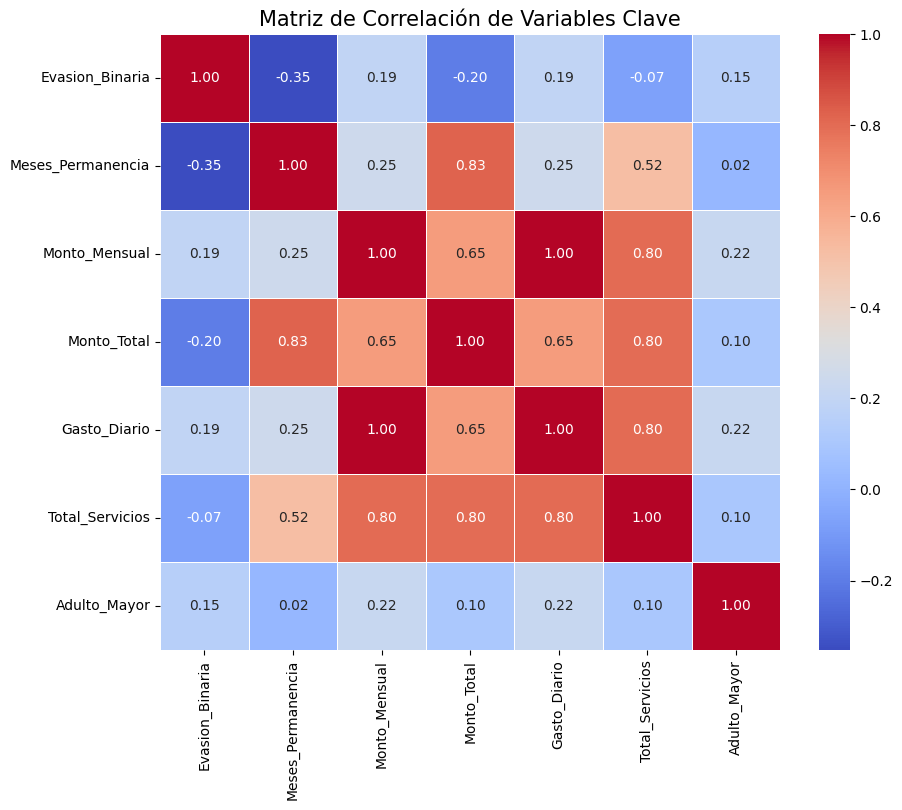

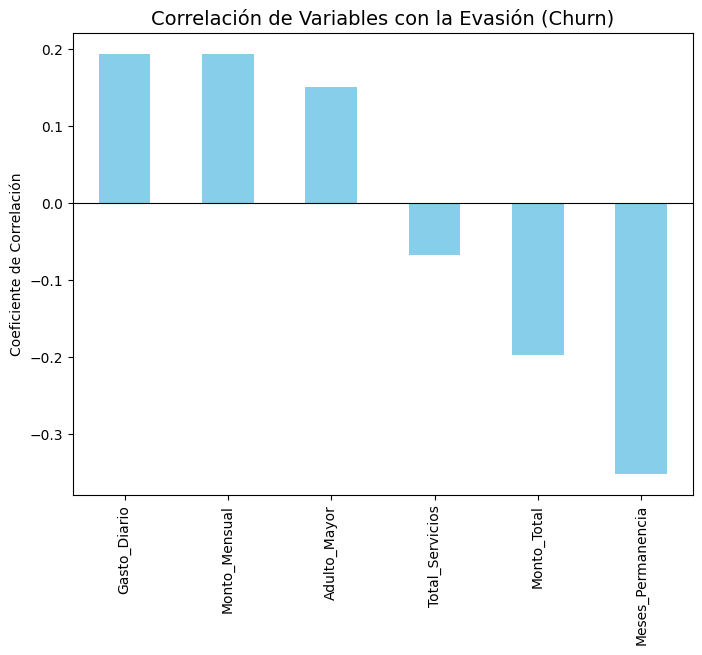

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- EXTRA: ANÁLISIS DE CORRELACIÓN ---

# 1. Ingeniería de Variables: Contar cantidad de servicios contratados
# Definimos las columnas que representan servicios adicionales
servicios = [
    'phone_PhoneService', 'phone_MultipleLines', 'internet_OnlineSecurity',
    'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport',
    'internet_StreamingTV', 'internet_StreamingMovies'
]

# Creamos la columna 'Total_Servicios' sumando cada vez que el valor es 'Yes'
df['Total_Servicios'] = df[servicios].apply(lambda x: x == 'Yes').sum(axis=1)

# 2. Seleccionamos solo las variables numéricas para la correlación
columnas_corr = [
    'Evasion_Binaria', 'Meses_Permanencia', 'Monto_Mensual',
    'Monto_Total', 'Gasto_Diario', 'Total_Servicios', 'Adulto_Mayor'
]
matriz_corr = df[columnas_corr].corr()

# 3. Visualización 1: Mapa de Calor (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables Clave', fontsize=15)
plt.show()

# 4. Visualización 2: Relación específica con la Evasión
plt.figure(figsize=(8, 6))
matriz_corr['Evasion_Binaria'].sort_values(ascending=False).drop('Evasion_Binaria').plot(kind='bar', color='skyblue')
plt.title('Correlación de Variables con la Evasión (Churn)', fontsize=14)
plt.ylabel('Coeficiente de Correlación')
plt.axhline(0, color='black', linewidth=0.8)
plt.show()